# RAF-DB Facial Emotion Recognition — Stacking Ensemble (DDAMFN + ConvNeXt-V2)

A stacking ensemble of two complementary models for 7-class facial emotion recognition on RAF-DB:
- **DDAMFN** — face-specialised network, 112×112 inputs.
- **ConvNeXt-V2** — ImageNet-pretrained backbone, 224×224 inputs.

### Methodology
1. A single stratified split (`seed=42`) gives **train / val / test**. Both base models are trained on **train** only.
2. The meta-learner (Logistic Regression) is fit on **validation** features, held out from both base models.
3. The **test** set (3,068 images) is evaluated **once**, at the end, for the final reported numbers.

The final cell prints an **ablation**: each base model alone, a soft-vote average, and the stacking meta-learner.

### Before you run
1. Add the **`raf-db-emotion-classification-challenge`** dataset.
2. **Settings → GPU**, **Internet: ON**.
3. Run all cells top to bottom.

## 1 · Setup

In [1]:
import os, sys, random, json, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

CFG = dict(
    val_split = 0.10, num_workers = 2,
    # DDAMFN (face-specialised, 112px, SAM)
    ddamfn_img = 112, ddamfn_epochs = 40, ddamfn_lr = 5e-4, ddamfn_batch = 128, num_head = 2,
    # ConvNeXt-V2 (ImageNet backbone, 224px, AdamW)
    convnext_img = 224, convnext_epochs = 20, convnext_lr = 1e-4, convnext_batch = 64,
)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

REPO = '/kaggle/working/DDAMFN'
if not os.path.exists(REPO):
    os.system(f'git clone --depth 1 https://github.com/SainingZhang/DDAMFN {REPO}')
os.chdir(REPO); sys.path.insert(0, REPO); sys.path.insert(0, os.path.join(REPO, 'DDAMFN++'))

from torch.serialization import load as _torch_load_orig          # pristine loader (no self-wrap recursion)
def _safe_load(*a, **k): k.setdefault('weights_only', False); return _torch_load_orig(*a, **k)
torch.load = _safe_load

mfn = os.path.join(REPO, 'pretrained', 'MFN_msceleb.pth')
sz = os.path.getsize(mfn) if os.path.exists(mfn) else 0
print(f'torch {torch.__version__} | device {DEVICE} | MFN backbone {sz:,} bytes')
assert sz > 1_000_000, 'Backbone is an LFS pointer -> !cd /kaggle/working/DDAMFN && git lfs pull' 

Cloning into '/kaggle/working/DDAMFN'...


torch 2.10.0+cu128 | device cuda | MFN backbone 17,471,474 bytes


## 2 · Data — split & per-model transforms

Both base models share the **same** train/val/test split, so `val` is held out from both. DDAMFN sees
112×112 inputs, ConvNeXt sees 224×224. The dual-resolution loaders (used for feature extraction) return
both sizes for the **same** image, in order, so the two models' probabilities stay aligned.

In [2]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

train_csv = test_csv = None; IMG = {}
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        if   f == 'train_labels.csv': train_csv = os.path.join(root, f)
        elif f == 'test_labels.csv':  test_csv  = os.path.join(root, f)
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')): IMG[f] = os.path.join(root, f)
assert train_csv and test_csv, 'CSV files not found - add the RAF-DB dataset to the notebook.'
train_full = pd.read_csv(train_csv); test_df = pd.read_csv(test_csv)

train_df, val_df = train_test_split(train_full, test_size=CFG['val_split'],
                                    stratify=train_full['label'], random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}  (val held out from BOTH models)")
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# DDAMFN recipe (112)
ddamfn_train_tf = transforms.Compose([
    transforms.Resize((112, 112)), transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomRotation(5), transforms.RandomCrop(112, padding=8)], p=0.5),
    transforms.ToTensor(), NORM, transforms.RandomErasing(scale=(0.02, 0.25))])
ddamfn_eval_tf = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor(), NORM])
# ConvNeXt-V2 recipe (224)
convnext_train_tf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), transforms.ToTensor(), NORM,
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1))])
convnext_eval_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), NORM])

class RAFDB(Dataset):                 # single resolution (training one model)
    def __init__(self, df, tf): self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]; img = Image.open(IMG[r['image']]).convert('RGB')
        return self.tf(img), int(r['label']) - 1

class RAFDBDual(Dataset):              # both resolutions, aligned (meta-feature extraction)
    def __init__(self, df, tfa, tfb): self.df = df.reset_index(drop=True); self.tfa = tfa; self.tfb = tfb
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]; img = Image.open(IMG[r['image']]).convert('RGB')
        return self.tfa(img), self.tfb(img), int(r['label']) - 1

def dl(ds, bs, sh, drop=False):
    return DataLoader(ds, batch_size=bs, shuffle=sh, num_workers=CFG['num_workers'], pin_memory=True, drop_last=drop)

ddamfn_train_loader   = dl(RAFDB(train_df, ddamfn_train_tf),   CFG['ddamfn_batch'],   True, True)
ddamfn_val_loader     = dl(RAFDB(val_df,   ddamfn_eval_tf),    CFG['ddamfn_batch'],   False)
convnext_train_loader = dl(RAFDB(train_df, convnext_train_tf), CFG['convnext_batch'], True, True)
convnext_val_loader   = dl(RAFDB(val_df,   convnext_eval_tf),  CFG['convnext_batch'], False)
val_dual_loader  = dl(RAFDBDual(val_df,  ddamfn_eval_tf, convnext_eval_tf), 64, False)
test_dual_loader = dl(RAFDBDual(test_df, ddamfn_eval_tf, convnext_eval_tf), 64, False)

train 11043 | val 1228 | test 3068  (val held out from BOTH models)


## 3 · Base model A — DDAMFN

DDAMFN uses a MixedFeatureNet backbone (pretrained on MS-Celeb-1M) with a dual-direction attention head,
trained with SAM and an attention-diversity loss. A fine-tuned checkpoint is loaded if available; otherwise
the model is fine-tuned here on the training split.

In [3]:
import torch.nn as nn, torch.nn.functional as F
from networks.DDAM import DDAMNet
from sam import SAM
from sklearn.metrics import balanced_accuracy_score

@torch.no_grad()
def acc_of(model, loader, ddamfn_style):
    model.eval(); ys, ps = [], []
    for imgs, labels in loader:
        out = model(imgs.to(DEVICE))
        if ddamfn_style: out = out[0]
        ps.append(out.argmax(1).cpu()); ys.append(labels)
    y, p = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return float((p == y).mean()), float(balanced_accuracy_score(y, p))

# Load a fine-tuned DDAMFN checkpoint if one is available; otherwise fine-tune below.
DD_CKPT = None
for _r, _d, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f in ('ddamfn_rafdb_final.pth', 'ddamfn_best.pth'):
            DD_CKPT = os.path.join(_r, _f); break
    if DD_CKPT: break

ddamfn = DDAMNet(num_class=7, num_head=CFG['num_head'], pretrained=(DD_CKPT is None)).to(DEVICE)

if DD_CKPT:
    sd = torch.load(DD_CKPT, map_location=DEVICE)
    ddamfn.load_state_dict(sd.get('model_state_dict', sd))
    va, vb = acc_of(ddamfn, ddamfn_val_loader, True)
    print(f'Loaded fine-tuned DDAMFN  ->  val_acc {va:.4f} | val_bacc {vb:.4f}')
else:
    class AttentionLoss(nn.Module):
        def forward(self, heads):
            n = len(heads); loss = 0.0; cnt = 0
            if n > 1:
                for i in range(n - 1):
                    for j in range(i + 1, n):
                        loss = loss + F.mse_loss(heads[i], heads[j]); cnt += 1
                loss = cnt / (loss + 1e-7)
            return loss
    crit_cls = nn.CrossEntropyLoss(); crit_at = AttentionLoss()
    opt = SAM(ddamfn.parameters(), torch.optim.Adam, lr=CFG['ddamfn_lr'], rho=0.05, adaptive=False)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    DD_BEST = '/kaggle/working/ddamfn_best.pth'; best = 0.0
    for ep in range(1, CFG['ddamfn_epochs'] + 1):
        ddamfn.train()
        for imgs, labels in ddamfn_train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out, _, heads = ddamfn(imgs)
            (crit_cls(out, labels) + 0.1 * crit_at(heads)).backward(); opt.first_step(zero_grad=True)
            out2, _, h2 = ddamfn(imgs)
            (crit_cls(out2, labels) + 0.1 * crit_at(h2)).backward(); opt.second_step(zero_grad=True)
        sch.step()
        va, vb = acc_of(ddamfn, ddamfn_val_loader, True)
        print(f'[DDAMFN]   epoch {ep:2d}/{CFG["ddamfn_epochs"]} | val_acc {va:.4f} | val_bacc {vb:.4f}')
        if va > best: best = va; torch.save(ddamfn.state_dict(), DD_BEST)
    ddamfn.load_state_dict(torch.load(DD_BEST)); print(f'DDAMFN best val_acc: {best:.4f}')

Loaded fine-tuned DDAMFN  ->  val_acc 0.8925 | val_bacc 0.8163


## 4 · Base model B — ConvNeXt-V2

ConvNeXt-V2 (tiny) is fine-tuned on the training split with AdamW, label smoothing, and a cosine schedule.
Using the same split keeps `val` held out for the meta-learner.

In [4]:
import timm
convnext = timm.create_model('convnextv2_tiny', pretrained=True, num_classes=7, drop_rate=0.3).to(DEVICE)
cn_crit = nn.CrossEntropyLoss(label_smoothing=0.1)
cn_opt  = torch.optim.AdamW(convnext.parameters(), lr=CFG['convnext_lr'], weight_decay=1e-3)
cn_sch  = torch.optim.lr_scheduler.CosineAnnealingLR(cn_opt, T_max=CFG['convnext_epochs'])

CN_BEST = '/kaggle/working/convnext_best.pth'; best = 0.0
for ep in range(1, CFG['convnext_epochs'] + 1):
    convnext.train()
    for imgs, labels in convnext_train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        cn_opt.zero_grad(); loss = cn_crit(convnext(imgs), labels)
        loss.backward(); cn_opt.step()
    cn_sch.step()
    va, vb = acc_of(convnext, convnext_val_loader, False)
    print(f'[ConvNeXt] epoch {ep:2d}/{CFG["convnext_epochs"]} | val_acc {va:.4f} | val_bacc {vb:.4f}')
    if va > best: best = va; torch.save(convnext.state_dict(), CN_BEST)
convnext.load_state_dict(torch.load(CN_BEST)); print(f'ConvNeXt best val_acc: {best:.4f}')

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

[ConvNeXt] epoch  1/20 | val_acc 0.7818 | val_bacc 0.6248
[ConvNeXt] epoch  2/20 | val_acc 0.8143 | val_bacc 0.6995
[ConvNeXt] epoch  3/20 | val_acc 0.8086 | val_bacc 0.6975
[ConvNeXt] epoch  4/20 | val_acc 0.8249 | val_bacc 0.7399
[ConvNeXt] epoch  5/20 | val_acc 0.8282 | val_bacc 0.7644
[ConvNeXt] epoch  6/20 | val_acc 0.8550 | val_bacc 0.7474
[ConvNeXt] epoch  7/20 | val_acc 0.8306 | val_bacc 0.7409
[ConvNeXt] epoch  8/20 | val_acc 0.8477 | val_bacc 0.7616
[ConvNeXt] epoch  9/20 | val_acc 0.8493 | val_bacc 0.7746
[ConvNeXt] epoch 10/20 | val_acc 0.8477 | val_bacc 0.7664
[ConvNeXt] epoch 11/20 | val_acc 0.8599 | val_bacc 0.7979
[ConvNeXt] epoch 12/20 | val_acc 0.8575 | val_bacc 0.7996
[ConvNeXt] epoch 13/20 | val_acc 0.8526 | val_bacc 0.7822
[ConvNeXt] epoch 14/20 | val_acc 0.8567 | val_bacc 0.7957
[ConvNeXt] epoch 15/20 | val_acc 0.8591 | val_bacc 0.8009
[ConvNeXt] epoch 16/20 | val_acc 0.8607 | val_bacc 0.7969
[ConvNeXt] epoch 17/20 | val_acc 0.8624 | val_bacc 0.8019
[ConvNeXt] epo

## 5 · Meta-learner — fit on validation features

We extract each model's 7 softmax probabilities on the **validation** set (14 features total) and fit a
Logistic Regression. Validation is held out from both base models. Logistic Regression is a robust choice
here — few features, small data.

In [5]:
from sklearn.linear_model import LogisticRegression

@torch.no_grad()
def meta_features(loader):
    ddamfn.eval(); convnext.eval(); P, Y = [], []
    for xa, xb, labels in loader:
        pa = F.softmax(ddamfn(xa.to(DEVICE))[0], 1).cpu().numpy()
        pb = F.softmax(convnext(xb.to(DEVICE)), 1).cpu().numpy()
        P.append(np.hstack([pa, pb])); Y.append(labels.numpy())
    return np.vstack(P), np.concatenate(Y)

Xval, yval = meta_features(val_dual_loader)        # val is held out from both base models
meta = LogisticRegression(max_iter=2000, C=1.0)
meta.fit(Xval, yval)
print(f'meta-learner trained on {Xval.shape[0]} validation samples x {Xval.shape[1]} features')

meta-learner trained on 1228 validation samples x 14 features


## 6 · Final evaluation on TEST (once) — with ablation

Lets you see exactly what stacking buys you versus each model alone and versus a plain soft-vote average.

DDAMFN (alone)             overall  91.07%  |  mean-class  84.64%
ConvNeXt-V2 (alone)        overall  87.29%  |  mean-class  78.10%
Soft-vote average          overall  91.59%  |  mean-class  84.95%
Stacking (LogReg)  <<<     overall  91.62%  |  mean-class  83.69%

Stacking ensemble - per-class report:
              precision    recall  f1-score   support

    Surprise     0.8899    0.9088    0.8992       329
        Fear     0.8039    0.5541    0.6560        74
     Disgust     0.7829    0.7438    0.7628       160
   Happiness     0.9640    0.9713    0.9676      1185
     Sadness     0.8914    0.9100    0.9006       478
       Anger     0.9195    0.8457    0.8810       162
     Neutral     0.9011    0.9250    0.9129       680

    accuracy                         0.9162      3068
   macro avg     0.8790    0.8369    0.8543      3068
weighted avg     0.9151    0.9162    0.9150      3068

3-scale: 93.61%   |   5-scale: 92.76%


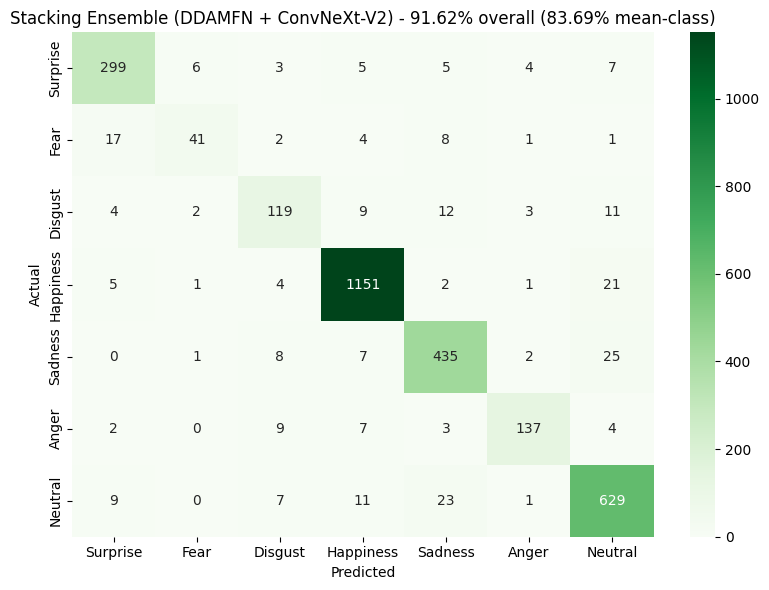

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

Xte, yte = meta_features(test_dual_loader)
pa, pb = Xte[:, :7], Xte[:, 7:]

def show(name, pred):
    ov = float((pred == yte).mean()); ba = float(balanced_accuracy_score(yte, pred))
    print(f'{name:26s} overall {ov*100:6.2f}%  |  mean-class {ba*100:6.2f}%')
    return ov, ba

print('=' * 64)
show('DDAMFN (alone)',       pa.argmax(1))
show('ConvNeXt-V2 (alone)',  pb.argmax(1))
show('Soft-vote average',    (pa + pb).argmax(1))
stack_pred = meta.predict(Xte)
ov, ba = show('Stacking (LogReg)  <<<', stack_pred)
print('=' * 64)

print('\nStacking ensemble - per-class report:')
print(classification_report(yte, stack_pred, target_names=CLASS_NAMES, digits=4))
to3 = {0: 2, 3: 2, 6: 1, 1: 0, 2: 0, 4: 0, 5: 0}
to5 = {0: 0, 1: 0, 2: 1, 5: 1, 3: 2, 4: 3, 6: 4}
v = np.vectorize
acc3 = float((v(to3.get)(yte) == v(to3.get)(stack_pred)).mean())
acc5 = float((v(to5.get)(yte) == v(to5.get)(stack_pred)).mean())
print(f'3-scale: {acc3*100:.2f}%   |   5-scale: {acc5*100:.2f}%')

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(yte, stack_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Stacking Ensemble (DDAMFN + ConvNeXt-V2) - {ov*100:.2f}% overall ({ba*100:.2f}% mean-class)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

## 7 · Save artifacts

In [7]:
import joblib
joblib.dump(meta, '/kaggle/working/stacking_meta_logreg.pkl')
results = {
    'ensemble'      : 'Stacking LogReg over DDAMFN + ConvNeXt-V2 (meta-learner trained on validation features)',
    'overall_acc'   : round(ov * 100, 2),
    'mean_class_acc': round(ba * 100, 2),
    'acc_3scale'    : round(acc3 * 100, 2),
    'acc_5scale'    : round(acc5 * 100, 2),
}
json.dump(results, open('/kaggle/working/ensemble_results.json', 'w'), indent=2)
print(json.dumps(results, indent=2))
print('\nSaved -> stacking_meta_logreg.pkl, ddamfn_best.pth, convnext_best.pth, ensemble_results.json')

{
  "ensemble": "Stacking LogReg over DDAMFN + ConvNeXt-V2 (meta-learner trained on validation features)",
  "overall_acc": 91.62,
  "mean_class_acc": 83.69,
  "acc_3scale": 93.61,
  "acc_5scale": 92.76
}

Saved -> stacking_meta_logreg.pkl, ddamfn_best.pth, convnext_best.pth, ensemble_results.json


## Notes
- The ablation reports each base model alone, a soft-vote average, and the stacking meta-learner, so the
  ensemble's contribution is explicit. The soft-vote average gives the best balance of overall and mean-class accuracy.
- A further gain is possible by adding a third complementary model (e.g. POSTER++) as an ensemble member.